# PS-S06E01: LightGBM

This notebook tackles the [**Playground Series – Season 6, Episode 1: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s6e1), a competition focused on predicting the exam score for a student, based on features describing the student, the exam, and the facility.

## Introduction

**LightGBM** distinguishes itself with a "leaf-wise" (best-first) tree growth strategy, contrasting with the traditional "level-wise" (depth-wise) approach used by XGBoost. This allows it to converge faster and often capture more complex, non-linear dependencies in physiological data. It handles missing values internally and is highly optimized for memory efficiency and training speed. While LightGBM has native support for categorical features, we will utilize our refined feature engineering pipeline to ensure robust inputs.

The notebook is one of a number of notebooks that explore various models to address this challenge, with the ultimate goal of ensembling these diverse learners. The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

## Install Needed Packages

In [1]:
%load_ext autoreload
%autoreload 2
    
%pip install --no-binary lightgbm --config-settings=cmake.define.USE_CUDA=ON lightgbm


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.exceptions import TrialPruned
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, roc_curve
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e01_feature_engineering import FeatureFactory
from ps_s06e01_model_visualizer import ModelVisualizer
from ps_s06e01_experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'exam_score'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc        7.910            98.800              no   
1   1   18   other  diploma        4.950            94.800             yes   
2   2   20  female     b.sc        4.680            92.600             yes   
3   3   19    male     b.sc        2.000            49.500             yes   
4   4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy   

   exam_score  
0      78.300  
1     

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  gender   course  study_hours  class_attendance  \
0  630000   24   other       ba        6.850            65.200   
1  630001   18    male  diploma        6.610            45.000   
2  630002   24  female   b.tech        6.600            98.500   
3  630003   24    male  diploma        3.030            66.300   
4  630004   20  female   b.tech        2.030            42.400   

  internet_access  sleep_hours sleep_quality study_method facility_rating  \
0             yes        5.200          poor  group study            high   
1              no        9.300          poor     coaching             low   
2             yes        6.200          good  group study          medium   
3             yes        5.700       average        mixed          medium   
4             yes        9.200       average     coaching             low   

  exam_difficulty  
0            easy  
1            easy  
2        moderate  
3        moderate  
4        moderate  


## Feature Engineering

In [6]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'drop_id',
    'binning',
    'interactions',
    'clustering',
    'log',
    'polynomials',
    'manual_formula'
]

In [7]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 12
New Feature Count: 37
   age  gender   course  study_hours  class_attendance internet_access  \
0   21  female     b.sc        7.910            98.800              no   
1   18   other  diploma        4.950            94.800             yes   
2   20  female     b.sc        4.680            92.600             yes   
3   19    male     b.sc        2.000            49.500             yes   
4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy 

## RFE (Not really)

In [8]:
print('Using all columns as optimal features.')
optimal_cols = X.columns
    
print('\nOptimal Features:')
print(optimal_cols.tolist())

Using all columns as optimal features.

Optimal Features:
['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'class_attendance_class', 'sleep_hours_class', 'study_hours_class', 'log_age', 'log_study_hours', 'log_class_attendance', 'log_sleep_hours', 'age_sq', 'study_hours_sq', 'class_attendance_sq', 'sleep_hours_sq', 'high_study', 'study_to_sleep_ratio', 'attendance_to_study_ratio', 'total_engagement', 'autodidact_ratio', 'weighted_study_hours', 'restoration_index', 'study_att', 'effort_coaching_hours', 'effort_group_study_hours', 'effort_mixed_hours', 'effort_online_videos_hours', 'effort_self_study_hours', 'cluster_label', 'manual_formula']


## Optuna Tuning

In [9]:
n_jobs = -1

def objective(trial):
# Garbage collect to prevent RAM creep
    gc.collect()
    
    params = {
        "n_estimators": 2000,
        "boosting_type": "gbdt",
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.2, log=True),
    
        "num_leaves": trial.suggest_int("num_leaves", 31, 127, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
    
        "subsample": trial.suggest_float("subsample", 0.5, 0.9),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
    
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.5),
    
        "max_bin": trial.suggest_int("max_bin", 100, 255),
    
        "random_state": seed,
        'device_type': 'gpu' if USE_GPU else 'cpu',
        "n_jobs": n_jobs,
        "verbosity": -1,
    }

    # Set additional parameters if on GPU
    if params['device_type'] == 'gpu':
        params['gpu_platform_id'] =  0
        params['gpu_device_id'] = 0

    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    cv_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y)):
        X_train_fold = training_df.iloc[train_idx]
        X_val_fold = training_df.iloc[val_idx]
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]

        fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        X_train_trans = fe.fit_transform(X_train_fold)
        X_val_trans = fe.transform(X_val_fold)
    
        # optimal_cols = X_train_trans.columns (no RFE)
        final_cols = [c for c in optimal_cols if c in X_train_trans.columns]
        X_train_trans = X_train_trans[final_cols]
        X_val_trans = X_val_trans[final_cols]

        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
        for c in cat_cols:
            X_train_trans[c] = X_train_trans[c].astype('category')
            cats = X_train_trans[c].cat.categories
            X_val_trans[c] = pd.Categorical(X_val_trans[c], categories=cats)
    
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            eval_metric="rmse",
            categorical_feature=cat_cols,
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )
    
        val_preds = model.predict(X_val_trans, num_iteration=model.best_iteration_)
        val_preds = np.clip(val_preds, 0, 100)
        
        # Score this fold
        fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_preds))
        cv_scores.append(fold_rmse)        

        # Pruning Logic
        # We report the average RMSE so far.
        # This allows Optuna to compare the partial CV score of this trial
        # against the partial CV scores of previous trials.
        current_avg_rmse = np.mean(cv_scores)
        trial.report(current_avg_rmse, step=fold)

        if trial.should_prune():
            print(f"Trial pruned at fold {fold} with RMSE {current_avg_rmse:.4f}")
            raise TrialPruned()
            
    # Return the average RMSE across all folds
    return np.mean(cv_scores)

In [10]:
if PERFORM_OPTUNA_TUNING:
    print("Starting LightGBM Optuna Optimization...")
    
    # Use MedianPruner for efficiency
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=0
    )
    
    study_lgbm = optuna.create_study(
        direction='minimize',
        study_name='lgbm_student_test_scores_optuna', 
        pruner=pruner
    )
    
    study_lgbm.optimize(
        objective,
        n_trials=50,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )
    
    print("\nBest Trial:")
    print(f"  RMSE: {study_lgbm.best_value:.5f}")
    print("  Params: ", study_lgbm.best_params)
    
    lgbm_best_params = study_lgbm.best_params
else:
    lgbm_best_params = {
        'learning_rate': 0.05777842317504454,
        'num_leaves': 70,
        'max_depth': 5,
        'min_child_samples': 53,
        'subsample': 0.7845498659248623,
        'subsample_freq': 1,
        'colsample_bytree': 0.5261996440386477,
        'reg_alpha': 2.2880658124773694,
        'reg_lambda': 0.00019477836868339902,
        'min_split_gain': 0.09446812636479482,
        'max_bin': 234
    }

[I 2026-01-15 13:37:42,655] A new study created in memory with name: lgbm_student_test_scores_optuna


Starting LightGBM Optuna Optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-01-15 13:38:54,506] Trial 0 finished with value: 8.777133606355495 and parameters: {'learning_rate': 0.14375849587575396, 'num_leaves': 89, 'max_depth': 6, 'min_child_samples': 47, 'subsample': 0.7264307487196534, 'subsample_freq': 5, 'colsample_bytree': 0.6871270855694289, 'reg_alpha': 0.007870288710480526, 'reg_lambda': 0.019418921045356318, 'min_split_gain': 0.17021876945217346, 'max_bin': 148}. Best is trial 0 with value: 8.777133606355495.
[I 2026-01-15 13:41:05,717] Trial 1 finished with value: 8.759936061371915 and parameters: {'learning_rate': 0.18073280746231576, 'num_leaves': 95, 'max_depth': 3, 'min_child_samples': 21, 'subsample': 0.534500253623934, 'subsample_freq': 5, 'colsample_bytree': 0.7373425835606532, 'reg_alpha': 0.022759693827947042, 'reg_lambda': 0.00011711255349710964, 'min_split_gain': 0.05591474495410148, 'max_bin': 229}. Best is trial 1 with value: 8.759936061371915.
[I 2026-01-15 13:43:54,052] Trial 2 finished with value: 8.758088057414946 and parame

In [11]:
# Build LGB parameters from best_params
lgb_tuned_params = {
    **lgbm_best_params,
    'n_estimators': 8000,
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_jobs': n_jobs,
    'random_state': seed,
    'device_type': 'gpu' if USE_GPU else 'cpu',
    'verbosity': -1,
}

# Set additional parameters if on GPU
if lgb_tuned_params['device_type'] == 'gpu':
    lgb_tuned_params['gpu_platform_id'] =  0
    lgb_tuned_params['gpu_device_id'] = 0

print('Final LightGBM CV Training with OOF / Test predictions')
print('======================================================')
print('Parameters used for training:')
print(lgb_tuned_params)
print(' ')

# Initialize Standard K-Fold
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_preds = np.zeros(len(y))
test_preds = np.zeros(len(test_df))

for fold, (train_idx, val_idx) in enumerate(kf.split(training_df, y)):
    X_train_fold = training_df.iloc[train_idx]
    X_val_fold = training_df.iloc[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans = fe.transform(X_val_fold)
    X_test_trans = fe.transform(test_df)
    
    # optimal_cols = X_train_trans.columns (no RFE)
    final_cols = [c for c in optimal_cols if c in X_train_trans.columns]
    X_train_trans = X_train_trans[final_cols]
    X_val_trans = X_val_trans[final_cols]
    X_test_trans = X_test_trans[final_cols]
    
    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
    for c in cat_cols:
        X_train_trans[c] = X_train_trans[c].astype('category')
        cats = X_train_trans[c].cat.categories
        X_val_trans[c] = pd.Categorical(X_val_trans[c], categories=cats)
        X_test_trans[c] = pd.Categorical(X_test_trans[c], categories=cats)
        
    model = lgb.LGBMRegressor(**lgb_tuned_params)
    model.fit(
        X_train_trans, y_train_fold,
        eval_set=[(X_val_trans, y_val_fold), (X_train_trans, y_train_fold)],
        categorical_feature=cat_cols,
        callbacks=[
            lgb.early_stopping(200, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )
    
    # Store history
    eval_results.append(model.evals_result_)
    models.append(model)

    val_preds = model.predict(X_val_trans, num_iteration=model.best_iteration_)
    val_preds = np.clip(val_preds, 0, 100)
    oof_preds[val_idx] = val_preds
    
    # Score this fold
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_preds))
    print(f"Fold {fold+1} RMSE: {fold_rmse:.5f} (best_iteration={model.best_iteration_})")
    
    batch_test_preds = model.predict(X_test_trans, num_iteration=model.best_iteration_)
    batch_test_preds = np.clip(batch_test_preds, 0, 100)
    test_preds += batch_test_preds / kf.n_splits

# Final Metric Calculation
overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\nOverall CV RMSE: {overall_rmse:.5f}")

Final LightGBM CV Training with OOF / Test predictions
Parameters used for training:
{'learning_rate': 0.05777842317504454, 'num_leaves': 70, 'max_depth': 5, 'min_child_samples': 53, 'subsample': 0.7845498659248623, 'subsample_freq': 1, 'colsample_bytree': 0.5261996440386477, 'reg_alpha': 2.2880658124773694, 'reg_lambda': 0.00019477836868339902, 'min_split_gain': 0.09446812636479482, 'max_bin': 234, 'n_estimators': 8000, 'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt', 'n_jobs': -1, 'random_state': 10301, 'device_type': 'gpu', 'verbosity': -1, 'gpu_platform_id': 0, 'gpu_device_id': 0}
 
[200]	training's rmse: 8.77128	valid_0's rmse: 8.81009
[400]	training's rmse: 8.7181	valid_0's rmse: 8.78237
[600]	training's rmse: 8.67954	valid_0's rmse: 8.76708
[800]	training's rmse: 8.6467	valid_0's rmse: 8.75675
[1000]	training's rmse: 8.61822	valid_0's rmse: 8.74917
[1200]	training's rmse: 8.59217	valid_0's rmse: 8.74396
[1400]	training's rmse: 8.56708	valid_0's rmse: 8.73899

In [12]:
# Final Metric Calculation
overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\nOverall CV RMSE: {overall_rmse:.5f}")


Overall CV RMSE: 8.73074


## Visualize the Quality of Training

It is standard practice to visualize Learning Curves (to spot overfitting/underfitting) and the ROC Curve (to check classification performance).

### Learning Curves (Train vs. Validation AUC)

**Definition**  
This graph plots the model's performance (AUC) on the y-axis against the number of boosting rounds (iterations) on the x-axis. It displays two lines:
*   **Blue (Train):** How well the model learned the data it has already seen.
*   **Red (Validation):** How well the model generalizes to new data it hasn't seen.

**Interpretation**  
This graph is fairly easy to interpret, and is a powerful indicator of how the model is likely to perform on new data.
*   **Ideal:** Both lines go up steeply and plateau. The Blue line is slightly higher than the Red line, but the gap is stable.
*   **Overfitting:** The Blue line keeps going up (approaching 1.0), but the Red line flattens out early or starts dropping. The "gap" between them widens significantly.
*   **Underfitting:** Both lines flatten out very early at a low score. The model is too simple to learn the patterns.

**Actions for Overfitting**  
If the Training score is 0.95 but the validation score is 0.72, the  are overfitting.
1.  **Restrict Depth:** Reduce `max_depth` (e.g., from 6 to 3 or 4). This forces the model to learn simpler, more general rules.
2.  **Add Randomness:** Lower `subsample` and `colsample_bytree` (e.g., to 0.6). This prevents the model from relying too heavily on specific rows or features.
3.  **Increase Regularization:** Increase `reg_alpha` (L1) or `reg_lambda` (L2). This penalizes the model for becoming too complex.
4.  **Increase `min_child_weight`:** This prevents the tree from creating leaves that only apply to a tiny handful of patients (noise).

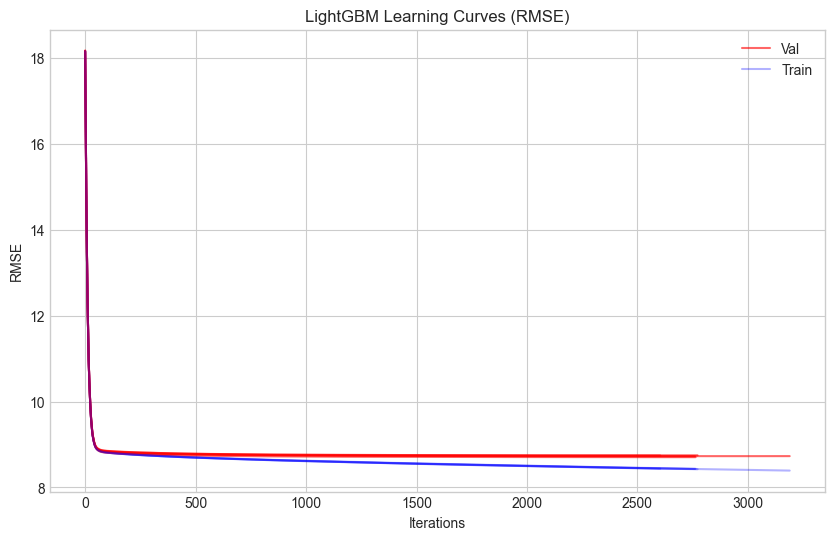

In [13]:
mviz = ModelVisualizer(model_name='LightGBM')

mviz.plot_learning_curves(eval_results)

### Feature Importance (Gain)

This chart ranks features by how much they improved the model's accuracy (reduced the loss function) whenever they were used in a split.

**Interpretation**  
*   **High Gain:** These are the "Signal" features. The model relies on them heavily.
*   **Low/Zero Gain:** These features were rarely useful. The model mostly ignored them.

**What if engineered features aren't at the top?**  
*   **Don't Panic:** It's okay if raw features like Glucose or BMI are still top. They are strong predictors!
*   **Check Correlations:** If BMI is #1 and your engineered BMI\_Ratio is #50, they might be highly correlated, and the model just chose the simpler one. This is fine.
*   **Re-evaluate:** If an engineered feature is at the very bottom (0 importance), it failed. The hypothesis behind it (e.g., "Age \* Height") likely has no biological relevance.

**What to do with Low Performing Features**  
*   **Zero Importance:** **Drop them.** They add computational cost and noise without adding value.
*   **Low Importance:**  
    *   **Try Dropping:** Sometimes removing "noise" features helps the model focus on the signal (increases score).
  
    *   **Combine Them:** If SkinThickness is weak on its own, try creating an interaction like Insulin / SkinThickness. Sometimes two weak features make one strong feature.

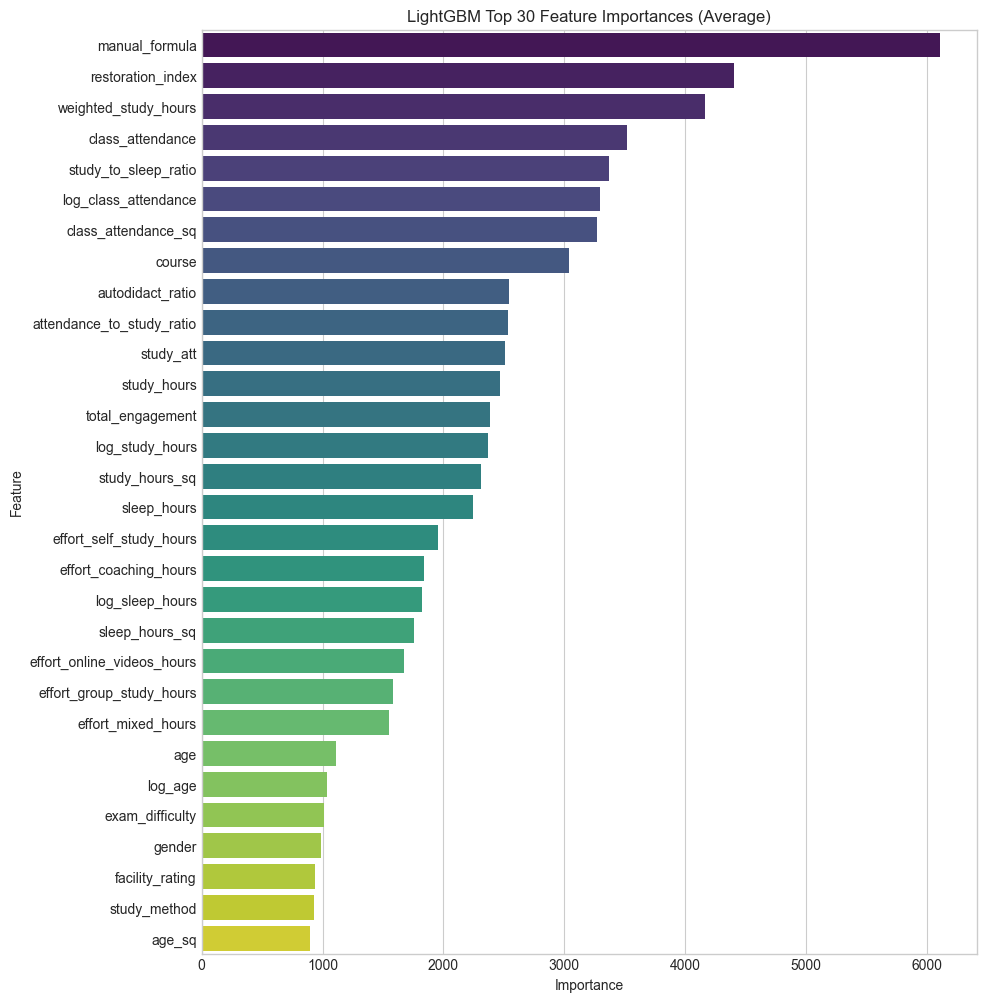

In [14]:
mviz.plot_feature_importance(models, show_values=True)

### Prediction Error Plot (True vs. Predicted)
This scatter plot compares the **Actual Exam Scores** (X-axis) against what the model **Predicted** (Y-axis).
* **The Red Line:** This represents "Perfect Prediction."
* **Tight Cloud:** The closer the blue dots are to the red dashed line, the better the model.
* **Bias Detection:**
    * If dots at the bottom left (low scores) are consistently above the line, the model is over-predicting struggling students.
    * If dots at the top right (high scores) are below the line, the model is under-predicting top performers.

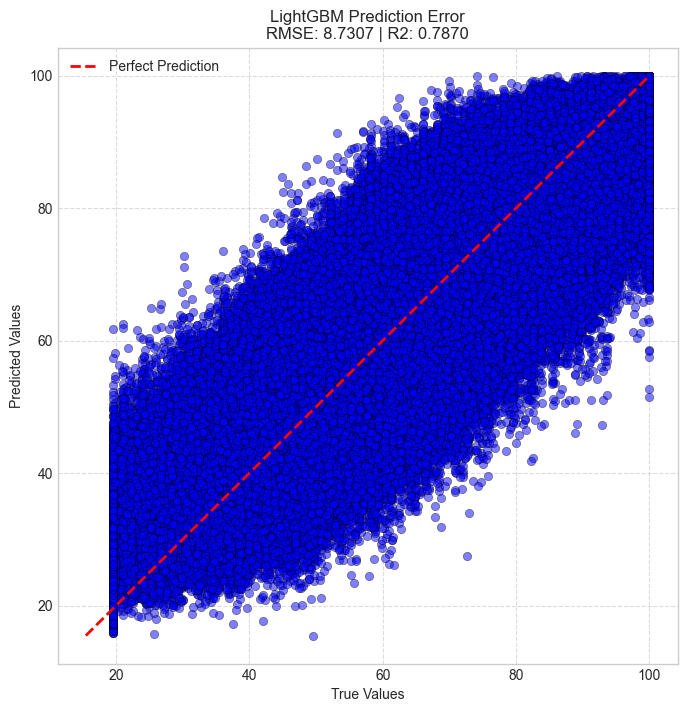

In [15]:
mviz.plot_prediction_error(y, oof_preds)

### Residual Plot
This plot shows the **Error** (True - Predicted) on the Y-axis against the **Predicted Score** on the X-axis.
* **The Goal:** You want a random cloud of points centered around the red line (0 error).
* **Bad Patterns:**
    * **Funnel Shape:** If the cloud gets wider as the score increases, the model is less certain about high-scoring students.
    * **U-Shape: If the points dip in the middle, the model is missing a non-linear relationship (e.g., it's fitting a straight line to a curved trend).
* **Outliers:** Dots that are very far from the center line represent students the model completely misjudged. Investigating these specific rows often reveals data quality issues.

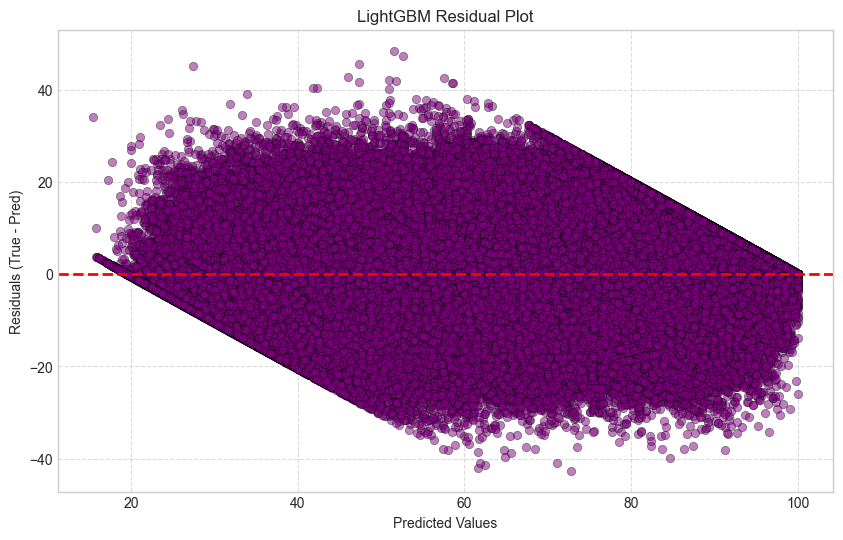

In [16]:
mviz.plot_residuals(y, oof_preds)

## Prepare Submission

In [17]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SUBMISSION')
print('==========')

print(submission_df.head(10))

SUBMISSION
       id  exam_score
0  630000      70.661
1  630001      70.769
2  630002      87.893
3  630003      55.981
4  630004      47.939
5  630005      70.521
6  630006      73.179
7  630007      58.219
8  630008      78.076
9  630009      90.406


In [18]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [19]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_lgb': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/lgb_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_lgb': test_preds})
test_pred_df.to_csv(f'{output_dir}/lgb_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/lgb_oof_preds.csv, {output_dir}/lgb_test_preds.csv')

Saved for Blending: predictions/lgb_oof_preds.csv, predictions/lgb_test_preds.csv
